# Machine Learning — Assignment 3

## Time Series Analysis using the MIT-BIH Arrhythmia Database

## Task 1 — Data Loading & Exploration

In [15]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

## Dataset Description

The MIT-BIH Arrhythmia Database is a publicly available ECG dataset from PhysioNet.
The signals are sampled at 360 Hz and each heartbeat is manually annotated by cardiologists.

For this assignment, we analyse 14 representative ECG records containing both normal rhythms and clinically significant arrhythmias.

In [16]:
records = [
    '100', '101', '105', '106',
    '108', '109', '111', '112',
    '115', '117', '119',
    '201', '213', '219'
]

print("Number of records:", len(records))

Number of records: 14


In [17]:
record = wfdb.rdrecord('100', pn_dir='mitdb')

In [18]:
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb')

In [19]:
print(record)

In [20]:
signal = record.p_signal[:,0]

print("Signal shape:", signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(ann.sample))

Signal shape: (650000,)
Sampling frequency: 360
Number of annotations: 2274


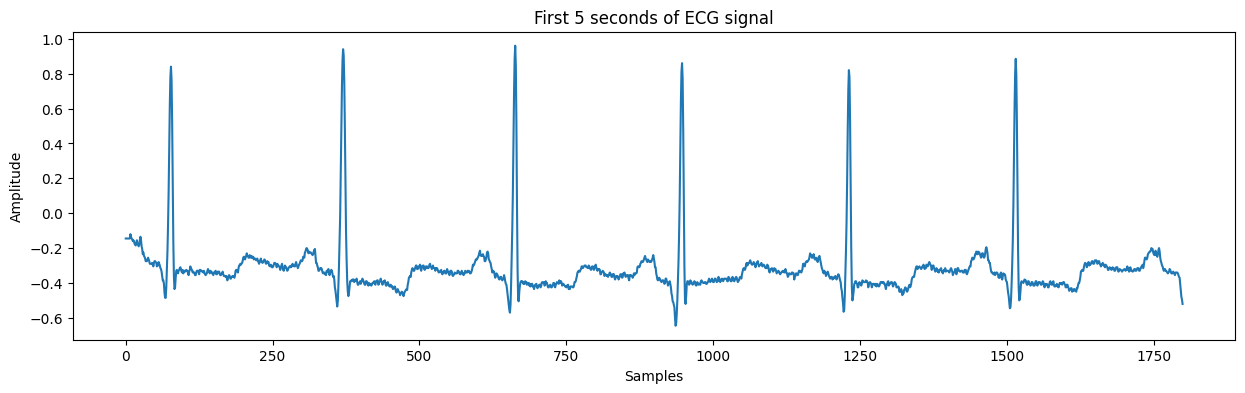

In [21]:
plt.figure(figsize=(15,4))

plt.plot(signal[:1800])

plt.title("First 5 seconds of ECG signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

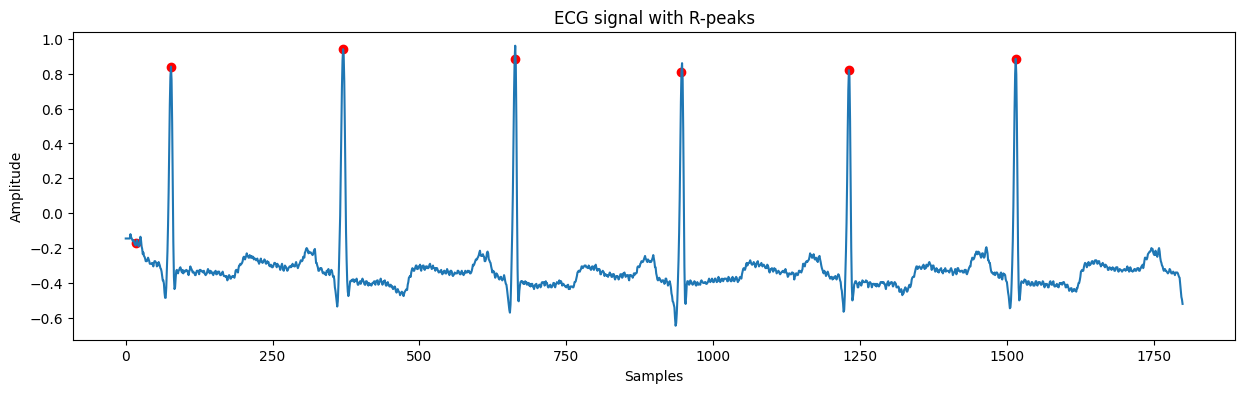

In [22]:
# Get R-peaks inside first 5 seconds
peaks = ann.sample[ann.sample < 1800]

plt.figure(figsize=(15,4))

plt.plot(signal[:1800])

plt.scatter(
    peaks,
    signal[peaks],
    color='red'
)

plt.title("ECG signal with R-peaks")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

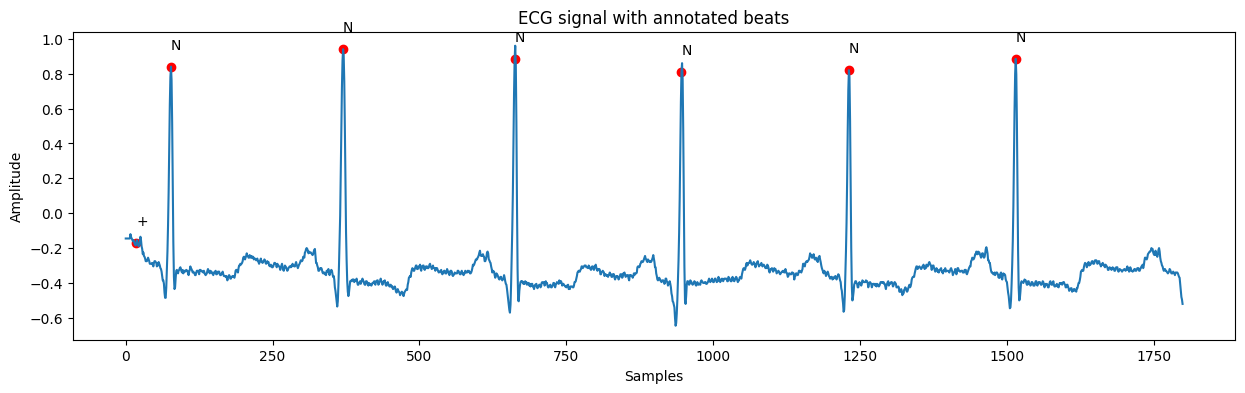

In [23]:
symbols = np.array(ann.symbol)[ann.sample < 1800]

plt.figure(figsize=(15,4))

plt.plot(signal[:1800])

plt.scatter(
    peaks,
    signal[peaks],
    color='red'
)

for p, s in zip(peaks, symbols):

    plt.text(
        p,
        signal[p] + 0.1,
        s
    )

plt.title("ECG signal with annotated beats")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [24]:
def plot_ecg_segment(record_id, start_sec=0, duration_sec=5):

    # Load record
    record = wfdb.rdrecord(record_id, pn_dir='mitdb')
    ann = wfdb.rdann(record_id, 'atr', pn_dir='mitdb')

    signal = record.p_signal[:,0]
    fs = record.fs

    # Define segment
    start = int(start_sec * fs)
    end = int((start_sec + duration_sec) * fs)

    # Extract signal segment
    segment = signal[start:end]

    # Extract peaks
    peaks = ann.sample[
        (ann.sample >= start) &
        (ann.sample < end)
    ]

    # Extract labels
    symbols = np.array(ann.symbol)[
        (ann.sample >= start) &
        (ann.sample < end)
    ]

    # Time axis
    time = np.arange(start, end) / fs

    # Plot
    plt.figure(figsize=(15,4))

    plt.plot(time, segment)

    plt.scatter(
        peaks / fs,
        signal[peaks],
        color='red'
    )

    # Add beat labels
    for p, s in zip(peaks, symbols):

        plt.text(
            p / fs,
            signal[p] + 0.1,
            s
        )

    plt.title(f"MIT-BIH Record {record_id}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude (mV)")
    plt.grid(True)

    plt.show()

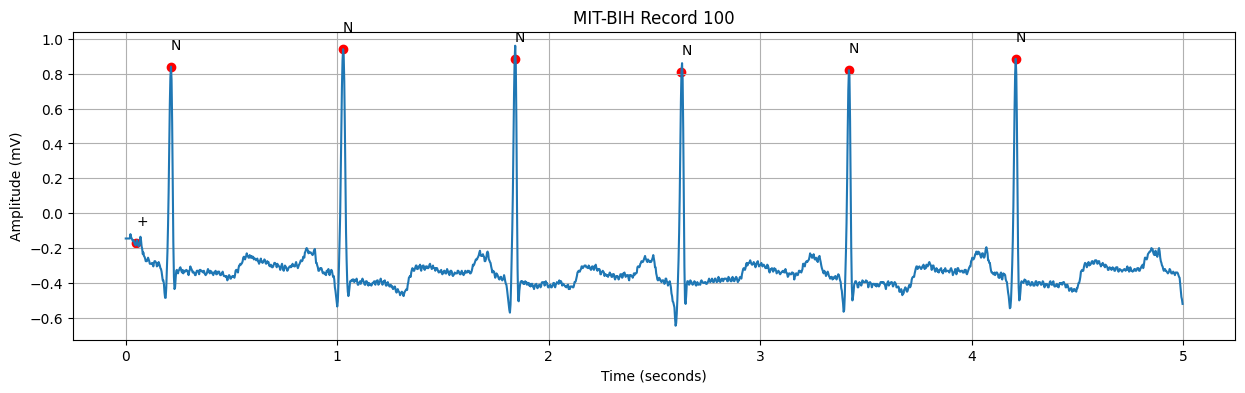

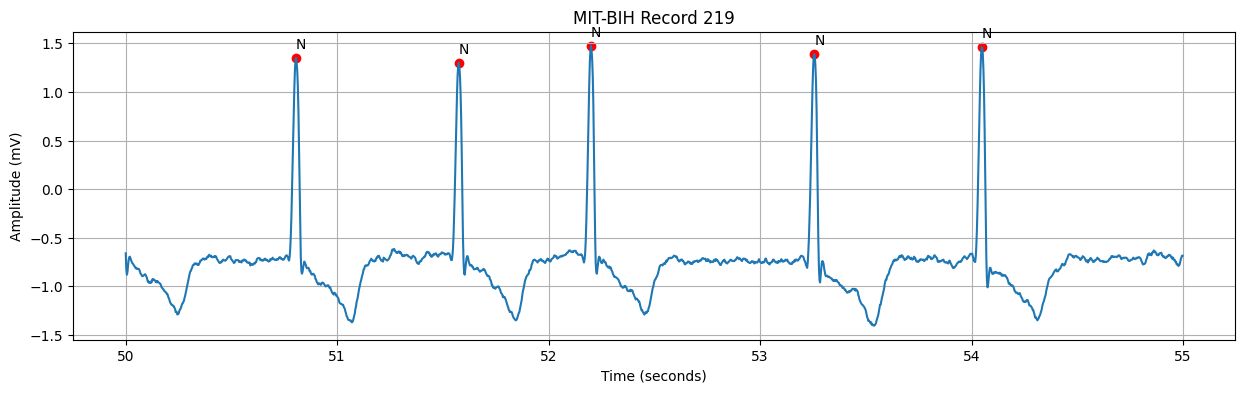

In [25]:
plot_ecg_segment('100', start_sec=0)

plot_ecg_segment('219', start_sec=50)

## ECG Signal Exploration

The ECG recordings were loaded directly from PhysioNet using the wfdb library.
For visual exploration, 5-second ECG segments were plotted together with the annotated R-peak locations provided by the dataset.

Record 100 mainly shows normal sinus rhythm, while record 219 contains a larger number of arrhythmic beats and rhythm variability.

In [26]:
label_map = {

    # Normal beats
    'N': 'N',
    '.': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # Supraventricular ectopic beats
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    # Ventricular ectopic beats
    'V': 'V',
    'E': 'V'
}

In [27]:
all_labels = []

for rec in records:

    ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    mapped_labels = [

        label_map[symbol]

        for symbol in ann.symbol

        if symbol in label_map
    ]

    all_labels.extend(mapped_labels)

class_counts = Counter(all_labels)

print(class_counts)

Counter({'N': 28412, 'V': 1544, 'S': 206})


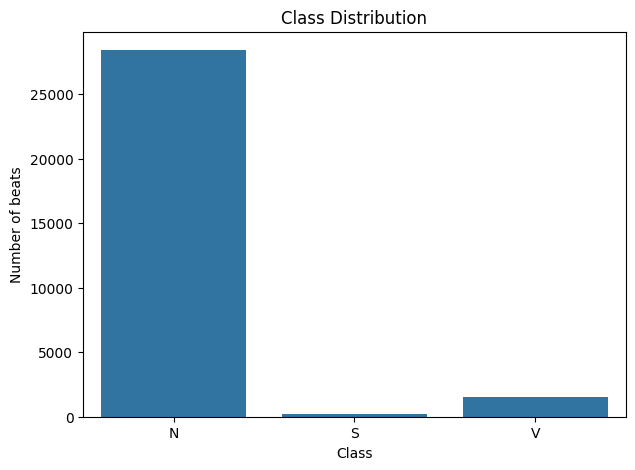

In [28]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of beats")

plt.show()

In [29]:
total_beats = sum(class_counts.values())

for cls, count in class_counts.items():

    percentage = (count / total_beats) * 100

    print(f"{cls}: {count} beats ({percentage:.2f}%)")

N: 28412 beats (94.20%)
S: 206 beats (0.68%)
V: 1544 beats (5.12%)


## Class Imbalance Discussion

The dataset is strongly imbalanced, with normal beats (N) representing the majority of samples, while supraventricular (S) and ventricular (V) beats are much less frequent.

This imbalance may bias machine learning models towards the majority class. A classifier predicting mostly normal beats could achieve high accuracy while failing to correctly detect clinically important arrhythmias.

For this reason, macro F1-score is more informative than accuracy in this task. Macro F1 evaluates each class equally regardless of frequency, making it more sensitive to minority-class performance.

This is particularly important in clinical applications, where false negatives in ventricular arrhythmias may have serious consequences for patient safety.